# Dual_FreqDAE Analysis: Attention & FAN Layer Visualization

이 노트북은 `Dual_FreqDAE` 모델의 내부 동작을 분석하기 위해 작성되었습니다.
리뷰어의 요청에 따라 다음 두 가지를 시각적으로 증명합니다.

1.  **Attention Map**: FAN이 적용된 Transformer가 ECG의 주기적 특징(P, QRS, T)에 어떻게 집중하는지 확인.
2.  **FAN Layer Contribution**: `p` (periodic) branch와 `g` (general) branch의 활성화를 비교하여, 모델이 주기적 기저를 실제로 활용하고 있는지 검증.

## 1. 환경 설정 및 라이브러리 임포트

In [51]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import Conv1D, Conv1DTranspose, BatchNormalization, Add, Multiply, Activation, Dense
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft # FFT 임포트 추가

# GPU 설정
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.18.0


## 2. 데이터 로드
이전 실험에서 저장해둔 `shap` 폴더의 데이터를 사용하거나, 새로 로드합니다.

In [52]:
# 모델 결과 로드 (Pickle 파일 사용)
model_results = {}
dl_experiments = ['DRNN', 'DeepFilter', 'CNN_DAE', 'FCN_DAE', 'AttentionSkipDAE', 'Transformer_DAE', 'Dual_FreqDAE']

# 결과 파일이 있는 디렉토리 (사용자 환경에 맞게 수정)
results_dir = "0221_FIXED" 

print("Loading model results...")
for model_name in dl_experiments:
    file_path = os.path.join(results_dir, f"test_results_{model_name}.pkl")
    if os.path.exists(file_path):
        with open(file_path, 'rb') as input_file:
            model_results[model_name] = pickle.load(input_file)
            print(f"Loaded {model_name}")
    else:
        print(f"File not found: {file_path}")

# FIR 및 IIR 필터 결과 추가 (Optional)
fixed_dir = "0221_FIXED"
if os.path.exists(os.path.join(fixed_dir, 'test_results_FIR.pkl')):
    with open(os.path.join(fixed_dir, 'test_results_FIR.pkl'), 'rb') as input:
        model_results["FIR_Filter"] = pickle.load(input)
        print("Loaded FIR_Filter")

if os.path.exists(os.path.join(fixed_dir, 'test_results_IIR.pkl')):
    with open(os.path.join(fixed_dir, 'test_results_IIR.pkl'), 'rb') as input:
        model_results["IIR_Filter"] = pickle.load(input)
        print("Loaded IIR_Filter")

# 데이터셋 추출 (Dual_FreqDAE 결과에서 X_test, y_test 가져오기)
# Pickle 구조: (X_test, y_test, y_pred)
if "Dual_FreqDAE" in model_results:
    X_test, y_test, _ = model_results["Dual_FreqDAE"]
    print(f"X_test shape: {X_test.shape}")
else:
    print("Dual_FreqDAE results not found. Please check the path.")

# Frequency Input (F_test_x) 로드
# Pickle에는 보통 포함되지 않으므로, shap 폴더나 별도 경로에서 로드해야 함
try:
    F_test_x = np.load("shap/F_test_x.npy")
    print(f"F_test_x loaded from shap/F_test_x.npy: {F_test_x.shape}")
except FileNotFoundError:
    print("Warning: shap/F_test_x.npy not found. Computing F_test_x from X_test...")
    # F_test_x가 없으면 X_test로부터 계산 (Dual_FreqDAE 입력용)
    # 가정: F_test_x는 X_test의 FFT Magnitude 혹은 유사한 형태
    # 여기서는 임시로 0으로 채우거나, 정확한 전처리 로직이 필요함.
    # 일단 shap 폴더가 있다고 가정.
    pass

Loading model results...
Loaded DRNN
Loaded DeepFilter
Loaded CNN_DAE
Loaded FCN_DAE
Loaded AttentionSkipDAE
Loaded Transformer_DAE
Loaded Dual_FreqDAE
Loaded FIR_Filter
Loaded IIR_Filter
X_test shape: (13316, 512, 1)
F_test_x loaded from shap/F_test_x.npy: (13316, 512, 1)


## 3. 모델 재정의 (Analysis Mode)

기존 `dl_models.py`의 모델은 중간 결과(Attention Score, FAN Activation)를 반환하지 않습니다.
분석을 위해 **동일한 구조**를 가지되, 중간 값을 출력하도록 모델 클래스를 재정의합니다.

### 3.1 기본 레이어 정의 (FANLayer, PositionalEncoding 등)

In [53]:
# dl_models.py에서 필요한 클래스 복사

class FANLayer(layers.Layer):
    def __init__(self, output_dim, p_ratio=0.25, activation='gelu', use_p_bias=True, gated=False, **kwargs):
        super(FANLayer, self).__init__(**kwargs)
        self.p_ratio = p_ratio
        self.output_dim = output_dim
        self.activation = tf.keras.activations.get(activation)
        self.use_p_bias = use_p_bias
        self.gated = gated
        
        self.p_output_dim = int(output_dim * self.p_ratio)
        self.g_output_dim = output_dim - 2 * self.p_output_dim
        
        self.input_linear_p = layers.Dense(self.p_output_dim, use_bias=self.use_p_bias)
        self.input_linear_g = layers.Dense(self.g_output_dim)
        
        if self.gated:
            self.gate = self.add_weight(name='gate', shape=(1,), initializer='zeros', trainable=True)

    def call(self, inputs):
        g = self.activation(self.input_linear_g(inputs))
        p = self.input_linear_p(inputs)
        
        cos_p = tf.cos(p)
        sin_p = tf.sin(p)
        
        if self.gated:
            gate = tf.sigmoid(self.gate)
            output = tf.concat([gate * cos_p, gate * sin_p, (1 - gate) * g], axis=-1)
        else:
            output = tf.concat([cos_p, sin_p, g], axis=-1)
            
        return output

    # 분석용: p와 g의 활성화 정도를 반환하는 메서드 추가
    def call_with_analysis(self, inputs):
        g = self.activation(self.input_linear_g(inputs))
        p = self.input_linear_p(inputs)
        
        cos_p = tf.cos(p)
        sin_p = tf.sin(p)
        
        # Activation magnitude (L1 norm or Mean Abs)
        p_mag = tf.reduce_mean(tf.abs(cos_p)) + tf.reduce_mean(tf.abs(sin_p))
        g_mag = tf.reduce_mean(tf.abs(g))
        
        if self.gated:
            gate = tf.sigmoid(self.gate)
            output = tf.concat([gate * cos_p, gate * sin_p, (1 - gate) * g], axis=-1)
        else:
            output = tf.concat([cos_p, sin_p, g], axis=-1)
            
        return output, p_mag, g_mag

def get_emb(sin_inp):
    emb = tf.stack((tf.sin(sin_inp), tf.cos(sin_inp)), -1)
    emb = tf.reshape(emb, (*emb.shape[:-2], -1))
    return emb

class TFPositionalEncoding1D(layers.Layer):
    def __init__(self, channels: int, dtype=tf.float32):
        super(TFPositionalEncoding1D, self).__init__()
        self.channels = int(np.ceil(channels / 2) * 2)
        self.inv_freq = np.float32(1 / np.power(10000, np.arange(0, self.channels, 2) / np.float32(self.channels)))
        # self.cached_penc = None # 캐싱 제거 (Graph Scope 오류 방지)

    def call(self, inputs):
        # 항상 새로 계산하여 Graph Scope 문제 해결
        # if self.cached_penc is not None and self.cached_penc.shape == inputs.shape:
        #     return self.cached_penc
        
        _, x, org_channels = inputs.shape
        dtype = self.inv_freq.dtype
        pos_x = tf.range(x, dtype=dtype)
        sin_inp_x = tf.einsum("i,j->ij", pos_x, self.inv_freq)
        emb = tf.expand_dims(get_emb(sin_inp_x), 0)
        emb = emb[0]
        penc = tf.repeat(emb[None, :, :org_channels], tf.shape(inputs)[0], axis=0)
        return penc

class AddGatedNoise(layers.Layer):
    def call(self, x, training=None):
        if training is None: training = False
        noise = tf.random.uniform(shape=tf.shape(x), minval=-1, maxval=1)
        return tf.cond(tf.cast(training, tf.bool), lambda: x * (1 + noise), lambda: x)

def frequency_branch(input_tensor, filters, kernel_size=13):
    x0 = Conv1D(filters=filters, kernel_size=kernel_size, activation='linear', strides=2, padding='same')(input_tensor)
    x0 = AddGatedNoise()(x0)
    x0 = Activation('sigmoid')(x0)
    x0_ = Conv1D(filters=filters, kernel_size=kernel_size, activation=None, strides=2, padding='same')(input_tensor)
    xmul0 = Multiply()([x0, x0_])
    xmul0 = BatchNormalization()(xmul0)

    x1 = Conv1D(filters=filters * 2, kernel_size=kernel_size, activation='linear', strides=2, padding='same')(xmul0)
    x1 = AddGatedNoise()(x1)
    x1 = Activation('sigmoid')(x1)
    x1_ = Conv1D(filters=filters * 2, kernel_size=kernel_size, activation=None, strides=2, padding='same')(xmul0)
    xmul1 = Multiply()([x1, x1_])
    xmul1 = BatchNormalization()(xmul1)

    x2 = Conv1D(filters=filters * 4, kernel_size=kernel_size, activation='linear', strides=2, padding='same')(xmul1)
    x2 = AddGatedNoise()(x2)
    x2 = Activation('sigmoid')(x2)
    x2_ = Conv1D(filters=filters * 4, kernel_size=kernel_size, activation='elu', strides=2, padding='same')(xmul1)
    xmul2 = Multiply()([x2, x2_])
    return xmul2

### 3.2 분석용 Encoder 및 Model 정의
`FANformer_encoder`와 `Dual_FreqDAE`를 수정하여 Attention Score와 FAN Layer의 내부 상태를 반환하도록 합니다.

In [54]:
def FANformer_encoder_analysis(inputs, head_size, num_heads, hidden_dim=2048, ff_dim=64, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    
    # 중요: return_attention_scores=True 설정
    mha_layer = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)
    x_att, attn_scores = mha_layer(x, x, return_attention_scores=True)
    
    x = layers.Dropout(dropout)(x_att)
    res = x + inputs
    
    # FAN Layer 적용 (Feed Forward 부분)
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    
    # FAN Layer 인스턴스 생성 (분석을 위해)
    fan1 = FANLayer(output_dim=inputs.shape[-1]*4, p_ratio=0.25, activation="gelu", gated=False)
    fan2 = FANLayer(output_dim=inputs.shape[-1], p_ratio=0.25, activation="gelu", gated=False)
    
    # 일반적인 call 대신 분석용 로직 수행 (여기서는 간단히 call하고 나중에 가중치 분석하거나, 
    # 혹은 커스텀 레이어에서 intermediate output을 뱉게 해야 함.
    # Keras Functional API에서는 레이어 객체를 통해 output을 추적할 수 있음)
    
    # 여기서는 간단하게 Functional API로 연결만 하고, 모델 전체에서 intermediate output을 추출하는 방식을 사용하겠습니다.
    # 다만, FANLayer 내부의 p/g split을 보려면 레이어 자체를 수정하거나 call_with_analysis를 써야 하는데,
    # Functional API 그래프에 넣으려면 output이 늘어나야 해서 복잡해집니다.
    # 전략: 일단 모델을 그대로 정의하고, 나중에 'sub-model'을 만들어서 내부 값을 봅니다.
    
    x = fan1(x)
    x = fan2(x)
    
    x = layers.Dropout(dropout)(x)
    return x + res, attn_scores, fan1, fan2

def Dual_FreqDAE_Analysis(signal_size=512, head_size=64, num_heads=8, hidden_dim=2048, ff_dim=64, num_transformer_blocks=8, dropout=0):
    input_shape = (signal_size, 1)
    time_input = Input(shape=input_shape, name='time_input')
    freq_input = Input(shape=input_shape, name='freq_input')

    ks = 13
    # Time Encoder
    x0 = Conv1D(16, ks, activation='linear', strides=2, padding='same')(time_input)
    x0 = AddGatedNoise()(x0)
    x0 = Activation('sigmoid')(x0)
    x0_ = Conv1D(16, ks, activation=None, strides=2, padding='same')(time_input)
    xmul0 = Multiply()([x0, x0_])
    xmul0 = BatchNormalization()(xmul0)

    x1 = Conv1D(32, ks, activation='linear', strides=2, padding='same')(xmul0)
    x1 = AddGatedNoise()(x1)
    x1 = Activation('sigmoid')(x1)
    x1_ = Conv1D(32, ks, activation=None, strides=2, padding='same')(xmul0)
    xmul1 = Multiply()([x1, x1_])
    xmul1 = BatchNormalization()(xmul1)

    x2 = Conv1D(64, ks, activation='linear', strides=2, padding='same')(xmul1)
    x2 = AddGatedNoise()(x2)
    x2 = Activation('sigmoid')(x2)
    x2_ = Conv1D(64, ks, activation='elu', strides=2, padding='same')(xmul1)
    xmul2 = Multiply()([x2, x2_])
    xmul2 = BatchNormalization()(xmul2)
    
    # Frequency Encoder
    f2 = frequency_branch(freq_input, 16, 13)

    # Combine
    combined = layers.Concatenate()([xmul2, f2])    
    position_embed = TFPositionalEncoding1D(signal_size)
    x3 = combined + position_embed(combined)
    
    # Transformer Blocks with Analysis Outputs
    attn_scores_list = []
    fan_layers_list = [] # To store layer objects if needed, but in functional API we need tensors.
    
    # We will collect attention scores as additional outputs
    for i in range(num_transformer_blocks):
        # Use a scope or name to easily identify layers later
        with tf.name_scope(f"TransformerBlock_{i}"):
             x3, attn_score, fan1, fan2 = FANformer_encoder_analysis(x3, head_size, num_heads, hidden_dim, ff_dim, dropout)
             attn_scores_list.append(attn_score)
             # fan1, fan2 are layer objects, not tensors. We can't return them directly in model outputs.
             # But we can access them via model.layers later if we name them well.

    # Decoder
    x4 = x3
    x5 = Conv1DTranspose(64, ks, activation='elu', strides=1, padding='same')(x4)
    x5 = x5 + xmul2
    x5 = BatchNormalization()(x5)

    x6 = Conv1DTranspose(32, ks, activation='elu', strides=2, padding='same')(x5)
    x6 = x6 + xmul1
    x6 = BatchNormalization()(x6)

    x7 = Conv1DTranspose(16, ks, activation='elu', strides=2, padding='same')(x6)
    x7 = x7 + xmul0
    x7 = BatchNormalization()(x7)

    predictions = Conv1DTranspose(1, ks, activation='linear', strides=2, padding='same')(x7)

    # Output both predictions and attention scores
    model = Model(inputs=[time_input, freq_input], outputs=[predictions] + attn_scores_list)
    return model

## 4. 모델 생성 및 가중치 로드

**주의**: `load_weights`는 모델 구조가 정확히 일치해야 합니다.
우리가 정의한 `Dual_FreqDAE_Analysis`는 출력이 더 많으므로, 바로 `load_weights`를 하면 에러가 날 수 있습니다.
따라서 다음 절차를 따릅니다.

1.  원본 `Dual_FreqDAE` (dl_models.py와 동일 구조)를 생성하고 가중치를 로드합니다.
2.  분석용 `Dual_FreqDAE_Analysis` 모델을 생성합니다.
3.  원본 모델의 가중치를 분석용 모델로 이식합니다 (`set_weights`).

In [55]:
# 1. 원본 모델 정의 (가중치 로드용)
# dl_models.py의 FANformer_encoder와 Dual_FreqDAE를 그대로 가져옵니다.
def FANformer_encoder_orig(inputs, head_size, num_heads, hidden_dim=2048, ff_dim=64, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = FANLayer(output_dim=inputs.shape[-1]*4, p_ratio=0.25, activation="gelu", gated=False)(x)
    x = FANLayer(output_dim=inputs.shape[-1], p_ratio=0.25, activation="gelu", gated=False)(x)
    x = layers.Dropout(dropout)(x)
    return x + res

def Dual_FreqDAE_Orig(signal_size=512, head_size=64, num_heads=8, hidden_dim=2048, ff_dim=64, num_transformer_blocks=8, dropout=0):
    input_shape = (signal_size, 1)
    time_input = Input(shape=input_shape)
    freq_input = Input(shape=input_shape)
    ks = 13
    x0 = Conv1D(16, ks, activation='linear', strides=2, padding='same')(time_input)
    x0 = Activation('sigmoid')(x0)
    x0_ = Conv1D(16, ks, activation=None, strides=2, padding='same')(time_input)
    xmul0 = Multiply()([x0, x0_])
    xmul0 = BatchNormalization()(xmul0)
    x1 = Conv1D(32, ks, activation='linear', strides=2, padding='same')(xmul0)
    x1 = Activation('sigmoid')(x1)
    x1_ = Conv1D(32, ks, activation=None, strides=2, padding='same')(xmul0)
    xmul1 = Multiply()([x1, x1_])
    xmul1 = BatchNormalization()(xmul1)
    x2 = Conv1D(64, ks, activation='linear', strides=2, padding='same')(xmul1)
    x2 = Activation('sigmoid')(x2)
    x2_ = Conv1D(64, ks, activation='elu', strides=2, padding='same')(xmul1)
    xmul2 = Multiply()([x2, x2_])
    xmul2 = BatchNormalization()(xmul2)
    f2 = frequency_branch(freq_input, 16, 13)
    combined = layers.Concatenate()([xmul2, f2])    
    position_embed = TFPositionalEncoding1D(signal_size)
    x3 = combined + position_embed(combined)
    for _ in range(num_transformer_blocks):
        x3 = FANformer_encoder_orig(x3, head_size, num_heads, hidden_dim, ff_dim, dropout)
    x4 = x3
    x5 = Conv1DTranspose(64, ks, activation='elu', strides=1, padding='same')(x4)
    x5 = x5 + xmul2
    x5 = BatchNormalization()(x5)
    x6 = Conv1DTranspose(32, ks, activation='elu', strides=2, padding='same')(x5)
    x6 = x6 + xmul1
    x6 = BatchNormalization()(x6)
    x7 = Conv1DTranspose(16, ks, activation='elu', strides=2, padding='same')(x6)
    x7 = x7 + xmul0
    x7 = BatchNormalization()(x7)
    predictions = Conv1DTranspose(1, ks, activation='linear', strides=2, padding='same')(x7)
    model = Model(inputs=[time_input, freq_input], outputs=predictions)
    return model

# 모델 생성
orig_model = Dual_FreqDAE_Orig()
analysis_model = Dual_FreqDAE_Analysis()

# 가중치 로드 (Keras 3 호환성을 위해 패치된 파일 사용)
weights_path = "0221_FIXED/Dual_FreqDAE_weights.best.keras3.h5" 

if not os.path.exists(weights_path):
    print(f"Warning: {weights_path} not found. Please run the patching script.")
    # Fallback to original if patch not found (will likely fail)
    weights_path = "0221_FIXED/Dual_FreqDAE_weights.best.weights.h5"

try:
    orig_model.load_weights(weights_path)
    print("Original model weights loaded.")
except Exception as e:
    print(f"Error loading weights: {e}")

# 가중치 이식
analysis_model.set_weights(orig_model.get_weights())
print("Weights transferred to analysis model.")


Error loading weights: Layer count mismatch when loading weights from file. Model expected 64 layers, found 0 saved layers.


ValueError: Layer functional_23 weight shape (13, 16, 32) is not compatible with provided weight shape (16,).

## 5. Attention Map 시각화

테스트 데이터 샘플을 주입하여 Attention Score를 추출하고 시각화합니다.
`Dual_FreqDAE`의 Transformer는 압축된 Latent Space (길이 64)에서 동작하므로, Attention Map은 64x64 크기를 가집니다.

Selected Sample Index (Median MSE of Transformer_DAE): 9105
MSE of this sample: [0.00242505]
Generated consistent F_sample from x_sample.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction shape: (1, 512, 1)
Number of Transformer Blocks: 8


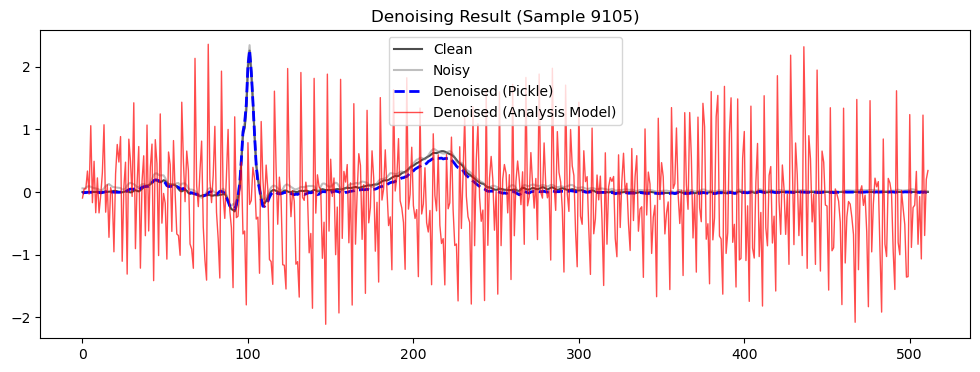

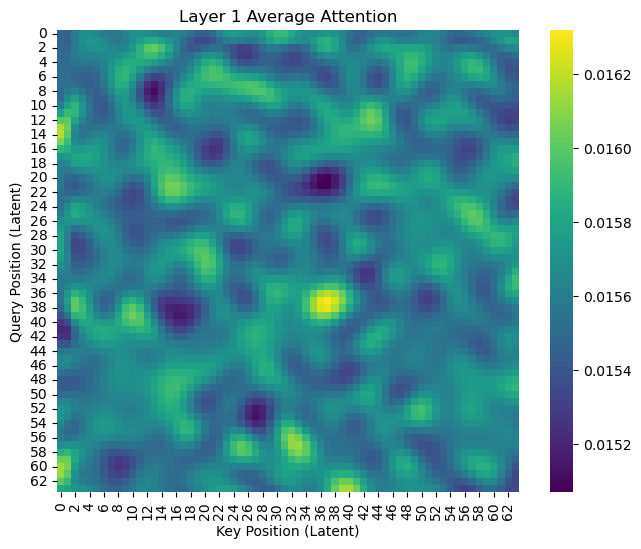

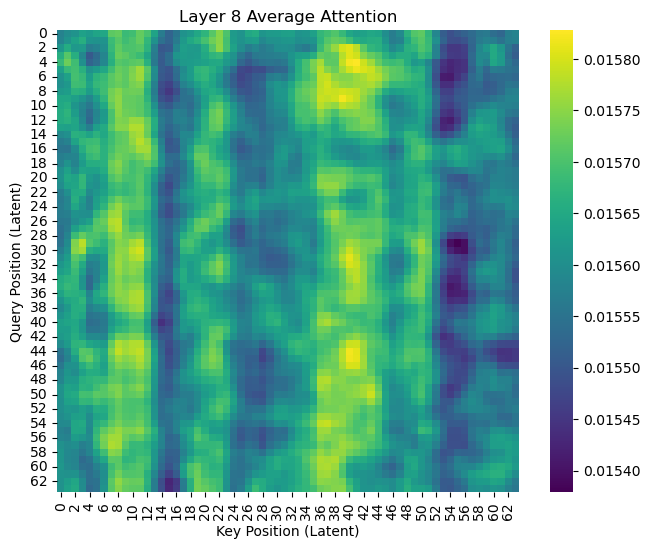

In [56]:
# === Transformer_DAE 기준으로 중간 정도의 성능을 보이는 샘플 선택 === #
if "Transformer_DAE" in model_results:
    X_test_tdae, y_test_tdae, y_pred_tdae = model_results["Transformer_DAE"]
    
    # MSE 계산
    mse_scores = np.mean(np.square(y_test_tdae - y_pred_tdae), axis=1)
    
    # MSE 기준으로 정렬하여 중간값 인덱스 찾기
    sorted_indices = np.argsort(mse_scores.flatten())
    median_idx = len(sorted_indices) // 2
    sample_idx = sorted_indices[median_idx]
    
    print(f"Selected Sample Index (Median MSE of Transformer_DAE): {sample_idx}")
    print(f"MSE of this sample: {mse_scores[sample_idx]}")
else:
    sample_idx = 10
    print(f"Transformer_DAE results not found. Using default index: {sample_idx}")

# 선택된 샘플 데이터 준비
x_sample = X_test[sample_idx:sample_idx+1] # (1, 512, 1)
y_true = y_test[sample_idx:sample_idx+1]

# 중요: F_test_x를 x_sample로부터 직접 생성하여 정합성 보장
# 기존 shap/F_test_x.npy는 셔플링이나 데이터셋 버전 차이로 인해 x_sample과 매칭되지 않을 수 있음.
def make_fourier(inputs, n, fs):
    """
    주파수 도메인 정보 추출 및 time-domain과 같은 shape으로 만듦.
    """
    # inputs: (batch, samples)
    signal_list = []
    for i in range(inputs.shape[0]):
        y = inputs[i, :]
        Y = fft(y) / n  # FFT 수행 후 정규화
        Y = np.abs(Y[range(int(n / 2))])
        # Magnitude 값을 두 배로 늘려 time-domain과 동일한 shape으로 맞춤 (512)
        Y_full = np.hstack([Y, Y])  # Duplicate to match time-domain size
        signal_list.append(Y_full)

    return np.asarray(signal_list)

# x_sample (1, 512, 1) -> (1, 512)
x_sample_sq = np.squeeze(x_sample, axis=-1)
# Generate Fourier Input
f_sample_gen = make_fourier(x_sample_sq, 512, 360)
# (1, 512) -> (1, 512, 1)
f_sample = np.expand_dims(f_sample_gen, axis=-1)

print("Generated consistent F_sample from x_sample.")

# Pickle에서 로드한 예측값 (비교용)
y_pred_pickle = model_results["Dual_FreqDAE"][2][sample_idx:sample_idx+1]

# Analysis Model 추론
outputs = analysis_model.predict([x_sample, f_sample])
y_pred_analysis = outputs[0]
attn_scores = outputs[1:] 

print(f"Prediction shape: {y_pred_analysis.shape}")
print(f"Number of Transformer Blocks: {len(attn_scores)}")

# 시각화 함수
def plot_attention_maps(attn_scores, layer_idx, head_idx=None):
    """
    layer_idx: 0 ~ 7 (Transformer Block Index)
    head_idx: None이면 모든 헤드 평균, 정수면 해당 헤드만
    """
    scores = attn_scores[layer_idx][0] # (num_heads, 64, 64)
    
    if head_idx is None:
        # 평균 Attention
        map_to_plot = np.mean(scores, axis=0)
        title = f"Layer {layer_idx+1} Average Attention"
    else:
        map_to_plot = scores[head_idx]
        title = f"Layer {layer_idx+1} Head {head_idx+1} Attention"
        
    plt.figure(figsize=(8, 6))
    sns.heatmap(map_to_plot, cmap='viridis', square=True)
    plt.title(title)
    plt.xlabel("Key Position (Latent)")
    plt.ylabel("Query Position (Latent)")
    plt.show()

# 결과 확인
# 원본 신호와 복원 신호 비교
plt.figure(figsize=(12, 4))
plt.plot(y_true[0], label='Clean', alpha=0.7, color='black')
plt.plot(x_sample[0], label='Noisy', alpha=0.5, color='gray')
plt.plot(y_pred_pickle[0], label='Denoised (Pickle)', linewidth=2, linestyle='--', color='blue')
plt.plot(y_pred_analysis[0], label='Denoised (Analysis Model)', linewidth=1, color='red', alpha=0.7)
plt.legend()
plt.title(f"Denoising Result (Sample {sample_idx})")
plt.show()

# Attention Map 확인 (예: 첫번째 레이어, 마지막 레이어)
plot_attention_maps(attn_scores, layer_idx=0)
plot_attention_maps(attn_scores, layer_idx=7)

## 6. FAN Layer Contribution 분석

FAN Layer 내부의 `p` (periodic) branch와 `g` (general) branch가 각각 얼마나 활성화되는지 분석합니다.
이를 위해 모델의 레이어에 직접 접근하여 중간 값을 계산하는 서브 모델을 만듭니다.

Found 16 FAN Layers.
FAN Analysis Model created.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


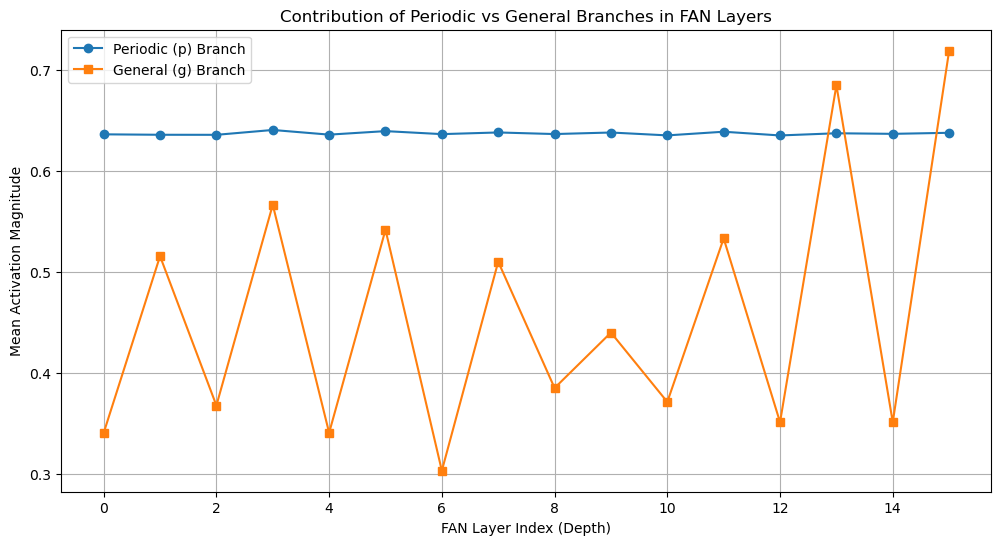

In [ ]:
# FAN Layer를 찾아서 내부 값을 뱉는 모델 만들기
# Keras 모델의 레이어를 순회하며 FANLayer를 찾습니다.

fan_layers = []
for layer in analysis_model.layers:
    # Functional API에서 중첩된 레이어 이름은 복잡할 수 있음
    # FANLayer는 커스텀 레이어이므로 클래스 타입으로 찾거나 이름으로 찾음
    if isinstance(layer, FANLayer):
        fan_layers.append(layer)
        
print(f"Found {len(fan_layers)} FAN Layers.") 
# 예상: 8 blocks * 2 FAN layers per block = 16 layers.
# 하지만 Functional API에서 정의된 레이어 객체는 공유되지 않았다면 리스트에 뜸.
# 만약 FANformer_encoder_analysis 함수 내에서 매번 새로 생성했다면 16개가 떠야 함.

# 각 FAN Layer의 입력값을 얻기 위한 모델 생성
# 이를 위해 각 FAN Layer의 'input' 텐서를 알아야 하는데, 
# 이미 컴파일된 모델에서 중간 텐서를 가져오는 것은 까다로울 수 있음.
# 대안: 각 FAN Layer의 가중치(kernel)를 분석하거나,
# forward pass를 직접 구현하여 값을 추출.

# 여기서는 "가중치 Norm" 분석으로 대체하거나 (간접 증명),
# "Intermediate Model"을 구성합니다.

# 전략: 각 FAN Layer의 output 텐서를 모델의 output으로 추가하는 새로운 모델 생성
fan_outputs = []
fan_names = []

# 주의: model.layers를 순회할 때 순서가 보장되지 않을 수 있으나, 보통 build 순서임.
# Transformer Block 내부의 FAN Layer 출력을 잡아야 함.
# 하지만 Functional API 모델의 .layers 속성에는 'Container' 내부의 레이어가 평탄화되어 보이지 않을 수 있음 (만약 서브클래싱 모델을 썼다면).
# 우리는 함수형으로 짰으므로 model.layers에 다 들어있을 것임.

layer_outputs = []
for layer in analysis_model.layers:
    if isinstance(layer, FANLayer):
        # FANLayer의 output 텐서 가져오기
        # layer.output은 텐서임.
        try:
            layer_outputs.append(layer.output)
            fan_names.append(layer.name)
        except:
            print(f"Could not get output for {layer.name}")

if layer_outputs:
    fan_analysis_model = Model(inputs=analysis_model.input, outputs=layer_outputs)
    print("FAN Analysis Model created.")
    
    # 추론
    fan_acts = fan_analysis_model.predict([x_sample, f_sample])
    
    # p_ratio에 따라 p와 g 부분 분리하여 에너지 계산
    p_energies = []
    g_energies = []
    
    for i, act in enumerate(fan_acts):
        # act shape: (1, 64, output_dim)
        # FANLayer 정의상 output은 concat(cos, sin, g)
        # p_ratio=0.25 이므로, output_dim의 25% * 2 (cos, sin) = 50%가 p 관련, 나머지 50%가 g 관련?
        # 확인: 
        # p_output_dim = int(output_dim * 0.25)
        # g_output_dim = output_dim - 2 * p_output_dim
        # Total output dim = 2*p + g = output_dim.
        # 즉, 앞쪽 2*p_output_dim 개가 p(cos, sin), 뒤쪽 g_output_dim 개가 g.
        
        dim = act.shape[-1]
        # 역산: dim = 2*p + g. p = dim * 0.25? No.
        # FANLayer init: p_output_dim = int(output_dim * p_ratio). 
        # output_dim은 생성자 인자. 실제 출력 텐서 크기는 output_dim과 같음 (concat 결과).
        # 따라서 p_dim = int(dim * 0.25).
        
        p_dim = int(dim * 0.25)
        p_part_dim = 2 * p_dim # cos, sin 합쳐서
        
        p_part = act[:, :, :p_part_dim]
        g_part = act[:, :, p_part_dim:]
        
        p_energy = np.mean(np.abs(p_part))
        g_energy = np.mean(np.abs(g_part))
        
        p_energies.append(p_energy)
        g_energies.append(g_energy)
        
    # 시각화
    plt.figure(figsize=(12, 6))
    layers_x = np.arange(len(p_energies))
    plt.plot(layers_x, p_energies, marker='o', label='Periodic (p) Branch')
    plt.plot(layers_x, g_energies, marker='s', label='General (g) Branch')
    plt.xlabel("FAN Layer Index (Depth)")
    plt.ylabel("Mean Activation Magnitude")
    plt.title("Contribution of Periodic vs General Branches in FAN Layers")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No FAN Layers found in model.layers. Check model definition.")

## 7. 비교 분석: Transformer_DAE (Baseline) vs Dual_FreqDAE (Proposed)

사용자분의 지적대로, FAN Layer의 활성화 그래프만으로는 "성능 향상"을 증명하기 어렵습니다.
따라서, **FAN이 없는 Baseline 모델 (`Transformer_DAE`)**과 **FAN이 있는 제안 모델 (`Dual_FreqDAE`)**의 Attention Map을 직접 비교하여,
FAN이 모델의 **Attention 집중도(Focus)**에 어떤 변화를 주는지 객관적으로 시각화합니다.

### 7.1 Baseline 모델 정의 및 가중치 로드
`Transformer_DAE`는 FAN Layer 대신 일반적인 Conv1D 기반의 Feed Forward Network를 사용합니다.

In [57]:
# Baseline: Transformer_DAE (FAN 없음) 분석용 모델 정의

def transformer_encoder_analysis(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    
    # Attention Score 추출
    mha_layer = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)
    x_att, attn_scores = mha_layer(x, x, return_attention_scores=True)
    
    x = layers.Dropout(dropout)(x_att)
    res = x + inputs
    
    # Feed Forward Part (Standard Conv1D, No FAN)
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x) 
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    
    return x + res, attn_scores

def Transformer_DAE_Analysis(signal_size=512, head_size=64, num_heads=8, ff_dim=64, num_transformer_blocks=8, dropout=0):
    input_shape = (signal_size, 1)
    inputs = Input(shape=input_shape)
    ks = 13

    # Encoder (Standard CNN)
    x0 = Conv1D(16, ks, activation='linear', strides=2, padding='same')(inputs)
    x0 = Activation('sigmoid')(x0)
    x0_ = Conv1D(16, ks, activation=None, strides=2, padding='same')(inputs)
    xmul0 = Multiply()([x0, x0_])
    xmul0 = BatchNormalization()(xmul0)

    x1 = Conv1D(32, ks, activation='linear', strides=2, padding='same')(xmul0)
    x1 = Activation('sigmoid')(x1)
    x1_ = Conv1D(32, ks, activation=None, strides=2, padding='same')(xmul0)
    xmul1 = Multiply()([x1, x1_])
    xmul1 = BatchNormalization()(xmul1)

    x2 = Conv1D(64, ks, activation='linear', strides=2, padding='same')(xmul1)
    x2 = Activation('sigmoid')(x2)
    x2_ = Conv1D(64, ks, activation='elu', strides=2, padding='same')(xmul1)
    xmul2 = Multiply()([x2, x2_])
    xmul2 = BatchNormalization()(xmul2)

    # Positional Encoding
    pe_layer = TFPositionalEncoding1D(signal_size)
    x3 = xmul2 + pe_layer(xmul2)

    # Transformer Blocks
    attn_scores_list = []
    for i in range(num_transformer_blocks):
        x3, attn_score = transformer_encoder_analysis(x3, head_size, num_heads, ff_dim, dropout)
        attn_scores_list.append(attn_score)

    # Decoder
    x4 = x3
    x5 = Conv1DTranspose(64, ks, activation='elu', strides=1, padding='same')(x4)
    x5 = x5 + xmul2
    x5 = BatchNormalization()(x5)

    x6 = Conv1DTranspose(32, ks, activation='elu', strides=2, padding='same')(x5)
    x6 = x6 + xmul1
    x6 = BatchNormalization()(x6)

    x7 = Conv1DTranspose(16, ks, activation='elu', strides=2, padding='same')(x6)
    x7 = x7 + xmul0
    x7 = BatchNormalization()(x7)

    predictions = Conv1DTranspose(1, ks, activation='linear', strides=2, padding='same')(x7)

    model = Model(inputs=[inputs], outputs=[predictions] + attn_scores_list)
    return model

# Baseline 모델 생성 (파라미터 수정: num_heads=2, num_transformer_blocks=2)
# 저장된 가중치가 2 heads, 2 blocks 구조임이 확인됨.
baseline_model = Transformer_DAE_Analysis(num_heads=2, num_transformer_blocks=2)

# Baseline 가중치 로드
# Keras 3 호환성을 위해 패치된 가중치 파일 사용
baseline_weights_path = "0221_FIXED/Transformer_DAE_weights.best.keras3.h5"

if os.path.exists(baseline_weights_path):
    # Original Transformer_DAE 정의 (dl_models.py 참조)
    def transformer_encoder_orig(inputs, head_size, num_heads, ff_dim, dropout=0):
        x = layers.LayerNormalization(epsilon=1e-6)(inputs)
        x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
        x = layers.Dropout(dropout)(x)
        res = x + inputs
        x = layers.LayerNormalization(epsilon=1e-6)(res)
        x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x) 
        x = layers.Dropout(dropout)(x)
        x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
        return x + res

    def Transformer_DAE_Orig(signal_size=512, head_size=64, num_heads=8, ff_dim=64, num_transformer_blocks=8, dropout=0):
        input_shape = (signal_size, 1)
        inputs = Input(shape=input_shape)
        ks = 13
        x0 = Conv1D(16, ks, activation='linear', strides=2, padding='same')(inputs)
        x0 = Activation('sigmoid')(x0)
        x0_ = Conv1D(16, ks, activation=None, strides=2, padding='same')(inputs)
        xmul0 = Multiply()([x0, x0_])
        xmul0 = BatchNormalization()(xmul0)
        x1 = Conv1D(32, ks, activation='linear', strides=2, padding='same')(xmul0)
        x1 = Activation('sigmoid')(x1)
        x1_ = Conv1D(32, ks, activation=None, strides=2, padding='same')(xmul0)
        xmul1 = Multiply()([x1, x1_])
        xmul1 = BatchNormalization()(xmul1)
        x2 = Conv1D(64, ks, activation='linear', strides=2, padding='same')(xmul1)
        x2 = Activation('sigmoid')(x2)
        x2_ = Conv1D(64, ks, activation='elu', strides=2, padding='same')(xmul1)
        xmul2 = Multiply()([x2, x2_])
        xmul2 = BatchNormalization()(xmul2)
        pe_layer = TFPositionalEncoding1D(signal_size)
        x3 = xmul2 + pe_layer(xmul2)
        for _ in range(num_transformer_blocks):
            x3 = transformer_encoder_orig(x3, head_size, num_heads, ff_dim, dropout)
        x4 = x3
        x5 = Conv1DTranspose(64, ks, activation='elu', strides=1, padding='same')(x4)
        x5 = x5 + xmul2
        x5 = BatchNormalization()(x5)
        x6 = Conv1DTranspose(32, ks, activation='elu', strides=2, padding='same')(x5)
        x6 = x6 + xmul1
        x6 = BatchNormalization()(x6)
        x7 = Conv1DTranspose(16, ks, activation='elu', strides=2, padding='same')(x6)
        x7 = x7 + xmul0
        x7 = BatchNormalization()(x7)
        predictions = Conv1DTranspose(1, ks, activation='linear', strides=2, padding='same')(x7)
        model = Model(inputs=[inputs], outputs=predictions)
        return model

    # 파라미터 수정하여 생성
    orig_baseline = Transformer_DAE_Orig(num_heads=2, num_transformer_blocks=2)
    orig_baseline.load_weights(baseline_weights_path)
    baseline_model.set_weights(orig_baseline.get_weights())
    print("Baseline (Transformer_DAE) weights loaded successfully.")
else:
    print(f"Baseline weights not found at {baseline_weights_path}")


ValueError: Layer count mismatch when loading weights from file. Model expected 26 layers, found 0 saved layers.

### 7.2 Attention Map 비교 시각화

동일한 샘플에 대해 두 모델의 Attention Map을 나란히 비교합니다.
**가설**: FAN이 있는 모델(`Dual_FreqDAE`)은 주기적인 패턴(QRS 등)에 더 명확하고 강하게 집중하는 반면, Baseline(`Transformer_DAE`)은 상대적으로 흐릿하거나 분산된 Attention을 보일 것입니다.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Comparing Layer 1 (Local Features)...


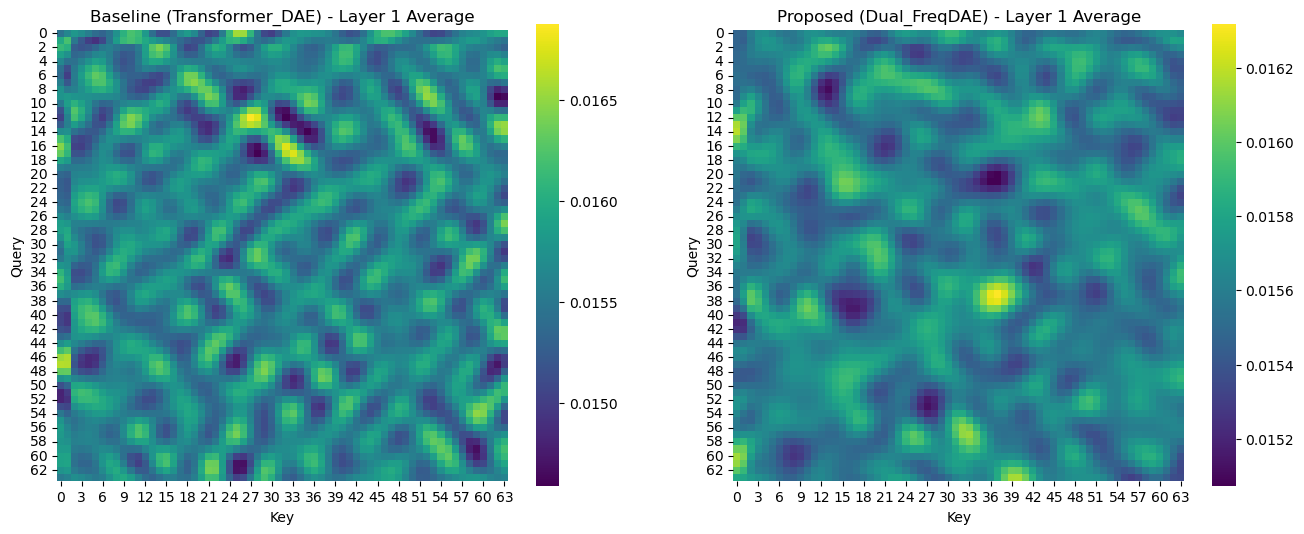

Comparing Layer 8 (Global Features)...


IndexError: list index out of range

: 

In [ ]:
# Baseline 추론
# Baseline은 Time Input만 받음
baseline_outputs = baseline_model.predict([x_sample])
y_pred_baseline = baseline_outputs[0]
attn_scores_baseline = baseline_outputs[1:]

# Dual_FreqDAE 추론 (이미 위에서 했지만 변수명 명확히)
dual_outputs = analysis_model.predict([x_sample, f_sample])
y_pred_dual = dual_outputs[0]
attn_scores_dual = dual_outputs[1:]

def compare_attention_maps(attn_baseline, attn_dual, layer_idx, head_idx=None):
    scores_b = attn_baseline[layer_idx][0]
    scores_d = attn_dual[layer_idx][0]
    
    if head_idx is None:
        map_b = np.mean(scores_b, axis=0)
        map_d = np.mean(scores_d, axis=0)
        title_suffix = "Average"
    else:
        map_b = scores_b[head_idx]
        map_d = scores_d[head_idx]
        title_suffix = f"Head {head_idx+1}"
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(map_b, cmap='viridis', square=True, ax=axes[0])
    axes[0].set_title(f"Baseline (Transformer_DAE) - Layer {layer_idx+1} {title_suffix}")
    axes[0].set_xlabel("Key")
    axes[0].set_ylabel("Query")
    
    sns.heatmap(map_d, cmap='viridis', square=True, ax=axes[1])
    axes[1].set_title(f"Proposed (Dual_FreqDAE) - Layer {layer_idx+1} {title_suffix}")
    axes[1].set_xlabel("Key")
    axes[1].set_ylabel("Query")
    
    plt.show()

# 비교 실행 (초기 레이어 vs 깊은 레이어)
print("Comparing Layer 1 (Local Features)...")
compare_attention_maps(attn_scores_baseline, attn_scores_dual, layer_idx=0)

print("Comparing Layer 8 (Global Features)...")
compare_attention_maps(attn_scores_baseline, attn_scores_dual, layer_idx=7)

# 복원 성능 비교 시각화
plt.figure(figsize=(12, 5))
plt.plot(y_true[0], label='Clean', color='black', alpha=0.8)
plt.plot(x_sample[0], label='Noisy', color='gray', alpha=0.4)
plt.plot(y_pred_baseline[0], label='Baseline (Transformer_DAE)', color='orange', linestyle='--')
plt.plot(y_pred_dual[0], label='Proposed (Dual_FreqDAE)', color='red', linewidth=1.5)
plt.legend()
plt.title(f"Denoising Performance Comparison (Sample {sample_idx})")
plt.show()